# Import the libraries

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt 

In [4]:
import mplfinance as mpf

In [5]:
from scipy import optimize 

In [6]:
import seaborn as sns

In [7]:
from matplotlib.ticker import PercentFormatter

In [8]:
import yfinance as yf 

# Data Collection: Historical, YTD, Technical and Monte Carlo

In [9]:
Tickers = ('LLY', 'NVO', 'SPY', 'XLV')
HIST = pd.DataFrame()
for t in Tickers:
    HIST[t] = yf.download(t, '2020-01-01','2026-01-01')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [10]:
HIST.head()

,LLY,NVO,SPY,XLV
Date,,,,
2020-01-02,122.406708,24.967995,295.391815,91.550423
2020-01-03,121.999329,24.433208,293.155060,90.752617
2020-01-06,122.452995,24.390425,294.273407,91.317345
2020-01-07,122.684433,24.364758,293.445892,91.138062
2020-01-08,123.795486,24.321972,295.009918,91.729683


In [11]:
HIST = HIST.rename(columns={"LLY": "Eli_Lilly"})

In [12]:
HIST = HIST.rename(columns={"NVO": "Novo_Nordisk"})

In [13]:
HIST = HIST.rename(columns={"SPY": "SP500"})

In [14]:
HIST = HIST.rename(columns={"XLV": "Healthcare"})

In [15]:
HIST.head()

,Eli_Lilly,Novo_Nordisk,SP500,Healthcare
Date,,,,
2020-01-02,122.406708,24.967995,295.391815,91.550423
2020-01-03,121.999329,24.433208,293.155060,90.752617
2020-01-06,122.452995,24.390425,294.273407,91.317345
2020-01-07,122.684433,24.364758,293.445892,91.138062
2020-01-08,123.795486,24.321972,295.009918,91.729683


In [16]:
Tickers = ('LLY', 'NVO', 'SPY', 'XLV')
YTD = pd.DataFrame()
for t in Tickers:
    YTD[t] = yf.download(t, '2026-01-01')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [17]:
YTD = YTD.rename(columns={"LLY": "Eli_Lilly"})

In [18]:
YTD = YTD.rename(columns={"NVO": "Novo_Nordisk"})

In [19]:
YTD = YTD.rename(columns={"SPY": "SP500"})

In [20]:
YTD = YTD.rename(columns={"XLV": "Healthcare"})

In [21]:
YTD.head()

,Eli_Lilly,Novo_Nordisk,SP500,Healthcare
Date,,,,
2026-01-02,1075.165771,49.898952,677.875305,153.605408
2026-01-05,1036.502441,52.489624,682.390076,153.141159
2026-01-06,1058.924194,53.584942,686.448364,156.153809
2026-01-07,1102.762329,53.880203,684.235657,157.704605
2026-01-08,1079.972412,54.613590,684.166199,156.183441


In [22]:
TECH = yf.download('LLY', '2025-09-23')

[*********************100%***********************]  1 of 1 completed


In [23]:
TECH.head()

Price,Close,High,Low,Open,Volume
Ticker,LLY,LLY,LLY,LLY,LLY
Date,,,,,
2025-09-23,742.298401,748.280691,738.512282,745.865928,2910100
2025-09-24,737.200500,742.258626,731.546160,741.314568,2243000
2025-09-25,710.111450,735.362170,707.587330,733.046756,5136400
2025-09-26,719.999023,724.431093,712.585817,719.581673,3559700
2025-09-29,721.956787,723.298302,711.592162,721.002782,3309200


In [24]:
TECH= TECH[['Open','High','Low','Close','Volume']]

In [25]:
TECH['50MA']= TECH['Close'].rolling(window = 50).mean()

In [26]:
TECH['100MA']= TECH['Close'].rolling(window = 100).mean()

In [27]:
TECH['200MA']=TECH['Close'].rolling(window = 200).mean()

In [28]:
TECH.head()

Price,Open,High,Low,Close,Volume,50MA,100MA,200MA
Ticker,LLY,LLY,LLY,LLY,LLY,,,
Date,,,,,,,,
2025-09-23,745.865928,748.280691,738.512282,742.298401,2910100,NaN,NaN,NaN
2025-09-24,741.314568,742.258626,731.546160,737.200500,2243000,NaN,NaN,NaN
2025-09-25,733.046756,735.362170,707.587330,710.111450,5136400,NaN,NaN,NaN
2025-09-26,719.581673,724.431093,712.585817,719.999023,3559700,NaN,NaN,NaN
2025-09-29,721.002782,723.298302,711.592162,721.956787,3309200,NaN,NaN,NaN


In [29]:
Monte = yf.download('LLY', '2023-09-23')['Close']

[*********************100%***********************]  1 of 1 completed


In [30]:
Monte.head()

Ticker,LLY
Date,
2023-09-25,541.028076
2023-09-26,538.794556
2023-09-27,538.549683
2023-09-28,533.348022
2023-09-29,526.177185


In [31]:
Monte = Monte.rename(columns={"LLY": "Eli_Lilly"})

In [32]:
Monte.head()

Ticker,Eli_Lilly
Date,
2023-09-25,541.028076
2023-09-26,538.794556
2023-09-27,538.549683
2023-09-28,533.348022
2023-09-29,526.177185


# DATASETS READY

In [33]:
HIST = HIST.dropna()

In [34]:
YTD = YTD.dropna()

In [35]:
Monte = Monte.dropna()

# Market Analysis: Return, Volatility, CAPM, Beta, Sortino, Drawdown and Charts 

# Historical Calculation 

In [36]:
C_RFR = 0.0528

In [37]:
S_RFR = 0.0286

In [38]:
SROR = HIST.pct_change()

In [39]:
AVG_SROR = SROR.mean()

In [40]:
ANN_EXPR = AVG_SROR*252

In [41]:
VAR = SROR.var()*252

In [42]:
COV = SROR.cov()*252

In [43]:
ANN_VOL = SROR.std()*np.sqrt(252)

In [44]:
Beta = COV['SP500']/VAR['SP500']

In [45]:
ERP = ANN_EXPR['SP500']-C_RFR

In [46]:
CAPM = C_RFR + Beta*ERP

In [47]:
Sharpe = (ANN_EXPR - S_RFR)/ANN_VOL

In [48]:
DAILY_RFR = ((1 + S_RFR) ** (1 / 252)) - 1

DOWNSIDE = (SROR - DAILY_RFR).clip(upper=0)

ANN_DWN = np.sqrt((DOWNSIDE ** 2).mean()) * np.sqrt(252)

In [49]:
Sortino = (ANN_EXPR - S_RFR)/ANN_DWN  

In [50]:
Sortino

Eli_Lilly       1.830794
Novo_Nordisk    0.576483
SP500           0.891310
Healthcare      0.576881
dtype: float64

In [51]:
Annual_Returns = (1+SROR).resample('YE').prod()-1

In [52]:
Hpeak = HIST.cummax()

In [53]:
Hdrawdown = (HIST - Hpeak)/Hpeak

In [54]:
HMax = Hdrawdown.min()

# Year Till Date Calculation 

In [55]:
Y_RFR = 0.0378

In [56]:
YTD_RET = (YTD.iloc[-1]/YTD.iloc[0]-1)

In [57]:
YSROR = YTD.pct_change()

In [58]:
YTD_VOL = YSROR.std()*np.sqrt(252)

In [59]:
YVAR = YSROR.var()*252

In [60]:
YCOV = YSROR.cov()*252

In [61]:
YBeta = YCOV['SP500']/YVAR['SP500']

In [62]:
Y_ERP = YTD_RET['SP500']-C_RFR

In [63]:
YCAPM = C_RFR + YBeta*Y_ERP

In [64]:
YSharpe = (YTD_RET - Y_RFR)/YTD_VOL

In [65]:
YDAILY_RFR = ((1 + Y_RFR) ** (1 / 252)) - 1

YDOWNSIDE = (YSROR - YDAILY_RFR).clip(upper=0)

ANN_YDWN = np.sqrt((YDOWNSIDE ** 2).mean()) * np.sqrt(252)

In [66]:
YSortino = (YTD_RET - Y_RFR)/ANN_YDWN

In [67]:
YPeak = YTD.cummax()

In [68]:
YDrawdown = (YTD - YPeak)/YPeak

In [69]:
YMax = YDrawdown.min()

# Visualization of Historical and Year till Date Performances

In [70]:
plt.rcParams.update({
    'figure.figsize': (12,6),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.linestyle':'--',
    'grid.alpha': 0.2,
    'axes.labelsize':11,
    'axes.titlesize': 14,
    'legend.frameon': False, 
    'font.size': 10})

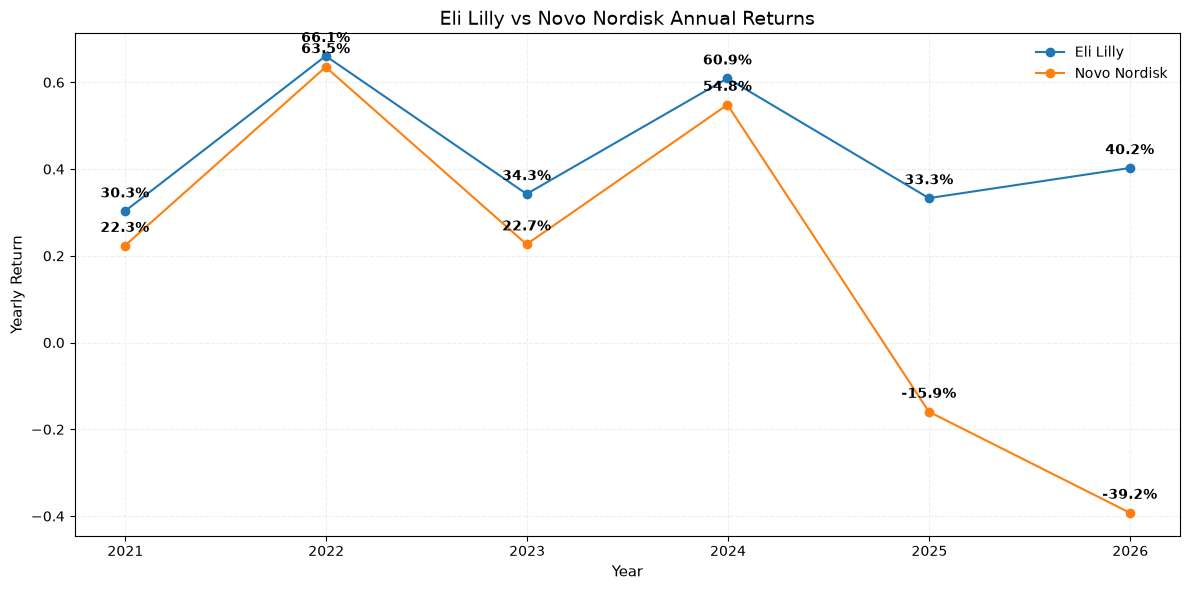

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    Annual_Returns.index,
    Annual_Returns['Eli_Lilly'].values,
    marker='o',
    label='Eli Lilly'
)
ax.plot(
    Annual_Returns.index,
    Annual_Returns['Novo_Nordisk'].values,
    marker='o',
    label='Novo Nordisk'
)
for year, yearly_return in Annual_Returns['Eli_Lilly'].items():
    ax.annotate(
        f'{yearly_return:.1%}',
        xy=(year, yearly_return),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

for year, yearly_return in Annual_Returns['Novo_Nordisk'].items():
    ax.annotate(
        f'{yearly_return:.1%}',
        xy=(year, yearly_return),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
ax.set_title('Eli Lilly vs Novo Nordisk Annual Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Yearly Return')
ax.legend()

fig.tight_layout()
plt.show()

In [72]:
fig.savefig('Lilly_vs_Novo.png', dpi = 300, bbox_inches = 'tight')

In [73]:
Normalized = HIST[['Eli_Lilly','Novo_Nordisk','SP500']]/HIST[['Eli_Lilly','Novo_Nordisk','SP500']].iloc[0]*100

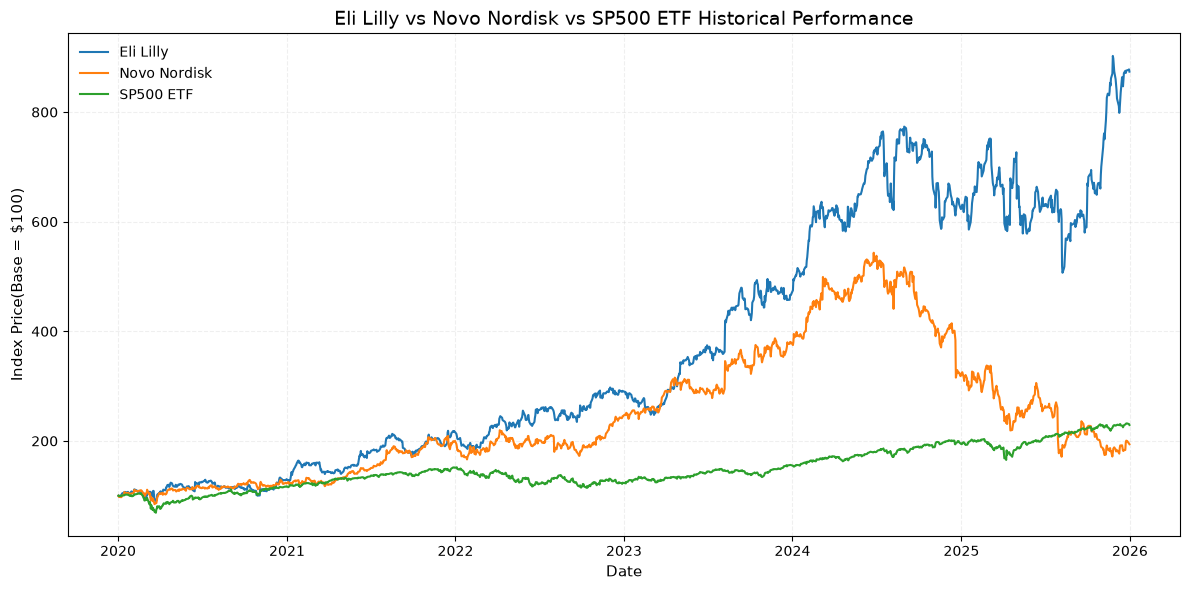

In [74]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(Normalized.index, 
       Normalized['Eli_Lilly'],
       label ='Eli Lilly')
ax.plot(Normalized.index,
       Normalized['Novo_Nordisk'],
       label = 'Novo Nordisk')
ax.plot(Normalized.index,
       Normalized['SP500'],
       label = 'SP500 ETF')

ax.set_title('Eli Lilly vs Novo Nordisk vs SP500 ETF Historical Performance')
ax.set_xlabel('Date')
ax.set_ylabel('Index Price(Base = $100)')
ax.legend()

fig.tight_layout()

plt.show()

In [75]:
fig.savefig('Eli_vs_novo_sp500.png', dpi = 300, bbox_inches='tight')

In [76]:
Normalized1 = YTD[['Eli_Lilly','Novo_Nordisk','SP500']]/YTD[['Eli_Lilly','Novo_Nordisk','SP500']].iloc[0]*100

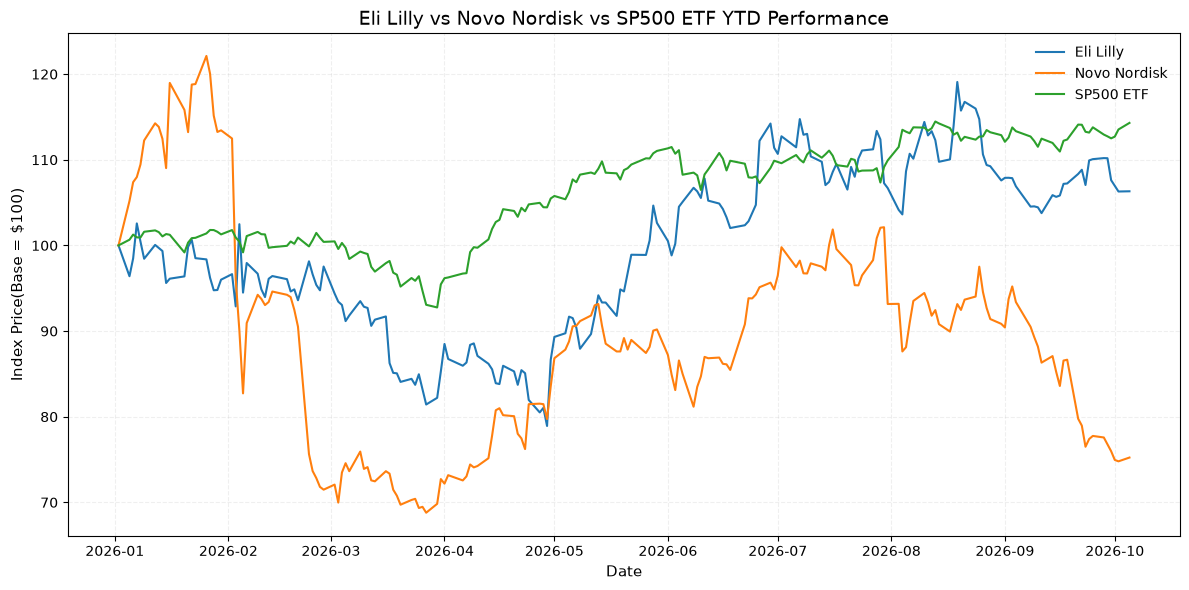

In [77]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(Normalized1.index, 
       Normalized1['Eli_Lilly'],
       label ='Eli Lilly')
ax.plot(Normalized1.index,
       Normalized1['Novo_Nordisk'],
       label = 'Novo Nordisk')
ax.plot(Normalized1.index,
       Normalized1['SP500'],
       label = 'SP500 ETF')

ax.set_title('Eli Lilly vs Novo Nordisk vs SP500 ETF YTD Performance')
ax.set_xlabel('Date')
ax.set_ylabel('Index Price(Base = $100)')
ax.legend()

fig.tight_layout()

plt.show()

In [78]:
fig.savefig('Eli_vs_novo_sp500_YTD.png', dpi = 300, bbox_inches='tight')

In [79]:
Ratio = pd.DataFrame({
    "Sharpe": Sharpe,
    "Sortino":Sortino
})

In [80]:
YRatio = pd.DataFrame({
    "Sharpe": YSharpe,
    "Sortino": YSortino
})

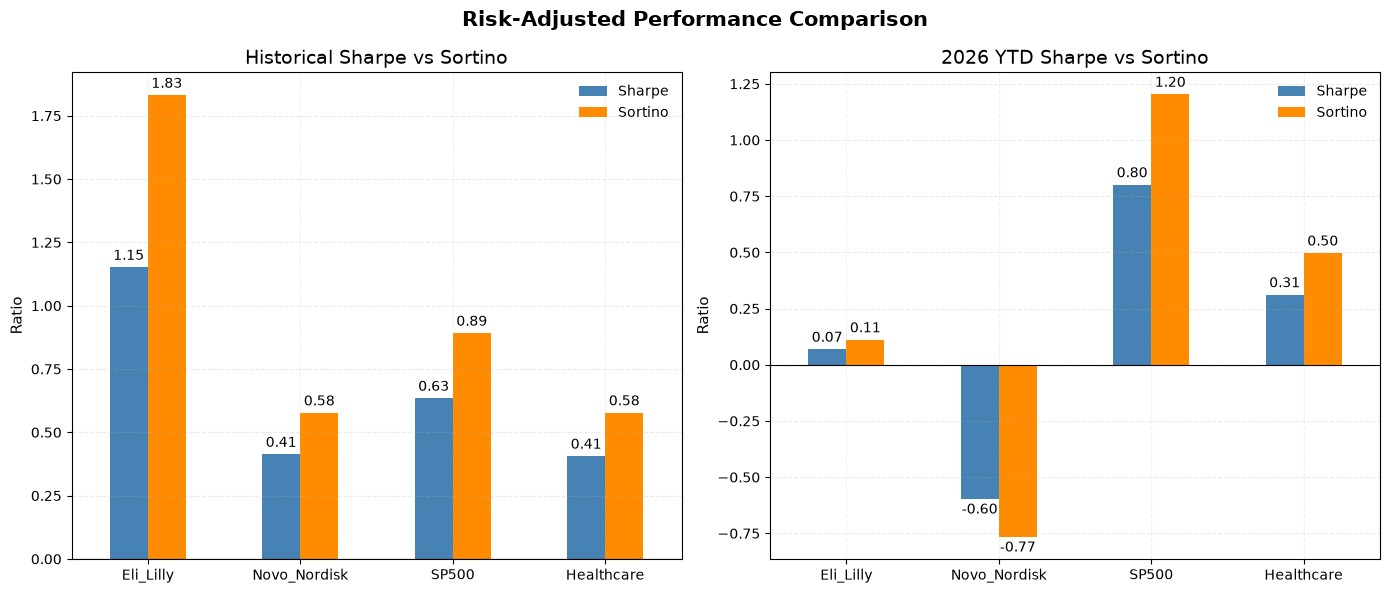

In [81]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

Ratio.plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "darkorange"]
)

YRatio.plot(
    kind="bar",
    ax=axes[1],
    color=["steelblue", "darkorange"]
)

axes[0].set_title("Historical Sharpe vs Sortino")
axes[1].set_title("2026 YTD Sharpe vs Sortino")

for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("Ratio")
    ax.tick_params(axis="x", rotation=0)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)

    for bars in ax.containers:
        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=3
        )

fig.suptitle(
    "Risk-Adjusted Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

fig.tight_layout()
plt.show()

In [82]:
fig.savefig('Risk_adjusted_performance.png', dpi=300, bbox_inches ='tight')

In [83]:
RISK = YTD[['Eli_Lilly']]

In [84]:
RISK['Return'] = RISK.pct_change()

In [85]:
RISK = RISK.dropna(subset=['Return'])

In [86]:
VAR95 = RISK['Return'].quantile(0.05)

In [87]:
tail_losses_95 = RISK.loc[
    RISK['Return'] <= VAR95,
    'Return'
]

In [88]:
CVAR = tail_losses_95.mean()

In [89]:
VAR_95 = -VAR95

In [90]:
CVAR= -CVAR

In [91]:
Return = RISK['Return']

In [129]:
VAR_LINE = -abs(VAR95)
CVAR_LINE = -abs(CVAR)

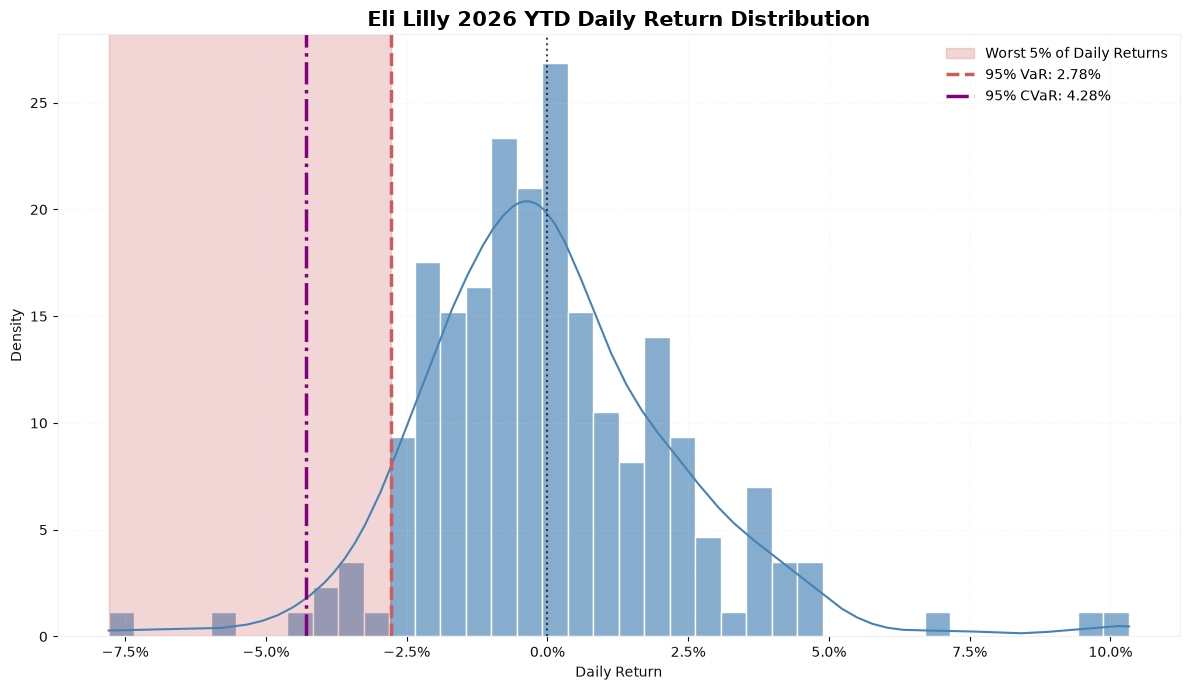

In [130]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.histplot(
    Return,
    bins=40,
    kde=True,
    stat="density",
    color="steelblue",
    alpha=0.65,
    edgecolor="white",
    ax=ax
)

ax.axvspan(
    Return.min(),
    VAR_LINE,
    color="indianred",
    alpha=0.25,
    label="Worst 5% of Daily Returns"
)

ax.axvline(
    VAR_LINE,
    color="indianred",
    linestyle="--",
    linewidth=2.5,
    label=f"95% VaR: {abs(VAR95):.2%}"
)

ax.axvline(
    CVAR_LINE,
    color="purple",
    linestyle="-.",
    linewidth=2.5,
    label=f"95% CVaR: {abs(CVAR):.2%}"
)

ax.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7
)

ax.set_title(
    "Eli Lilly 2026 YTD Daily Return Distribution",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")

ax.xaxis.set_major_formatter(PercentFormatter(1))

ax.grid(alpha=0.15)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [131]:
fig.savefig('Eli_lilly_var&cvar.png', dpi =300, bbox_inches='tight')

In [94]:
sma50 = mpf.make_addplot(TECH['50MA'], color='blue',width=0.8)
sma100 = mpf.make_addplot(TECH['100MA'], color='orange',width=1.5)
sma200 = mpf.make_addplot(TECH['200MA'],color='purple', width=1.5)

In [95]:
mc = mpf.make_marketcolors(
    up="#1a9850",
    down="#d73027",
    edge="inherit",
    wick="inherit",
    volume="inherit"
)

In [96]:
style = mpf.make_mpf_style(base_mpf_style ='yahoo',
                           marketcolors = mc,
                           gridstyle = '--',
                           gridcolor = 'grey',
                           facecolor ='white',
                           figcolor = 'white',
                           y_on_right = False,
                           rc = {'font.size':10})

In [97]:
TECH.head()

Price,Open,High,Low,Close,Volume,50MA,100MA,200MA
Ticker,LLY,LLY,LLY,LLY,LLY,,,
Date,,,,,,,,
2025-09-23,745.865928,748.280691,738.512282,742.298401,2910100,NaN,NaN,NaN
2025-09-24,741.314568,742.258626,731.546160,737.200500,2243000,NaN,NaN,NaN
2025-09-25,733.046756,735.362170,707.587330,710.111450,5136400,NaN,NaN,NaN
2025-09-26,719.581673,724.431093,712.585817,719.999023,3559700,NaN,NaN,NaN
2025-09-29,721.002782,723.298302,711.592162,721.956787,3309200,NaN,NaN,NaN


In [98]:
TECH.tail()

Price,Open,High,Low,Close,Volume,50MA,100MA,200MA
Ticker,LLY,LLY,LLY,LLY,LLY,,,
Date,,,,,,,,
2026-09-29,1186.050049,1192.939941,1168.469971,1184.630005,1658100,1177.669648,1144.246995,1069.511357
2026-09-30,1186.489990,1215.000000,1155.270020,1157.079956,3407700,1177.336685,1146.098876,1070.274121
2026-10-01,1155.000000,1158.719971,1139.849976,1149.849976,2172500,1177.106768,1148.142723,1070.910522
2026-10-02,1153.819946,1164.920044,1136.660034,1142.849976,2052300,1176.280305,1149.931753,1071.339357
2026-10-05,1150.760010,1165.729980,1139.500000,1143.119995,1976600,1175.256333,1151.495403,1071.808852


In [99]:
TECH.columns = TECH.columns.get_level_values(0)
TECH.columns.name = None

In [100]:
TECH.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', '50MA', '100MA', '200MA'], dtype='str')

findfont: Failed to find font weight semibold, now using 700.


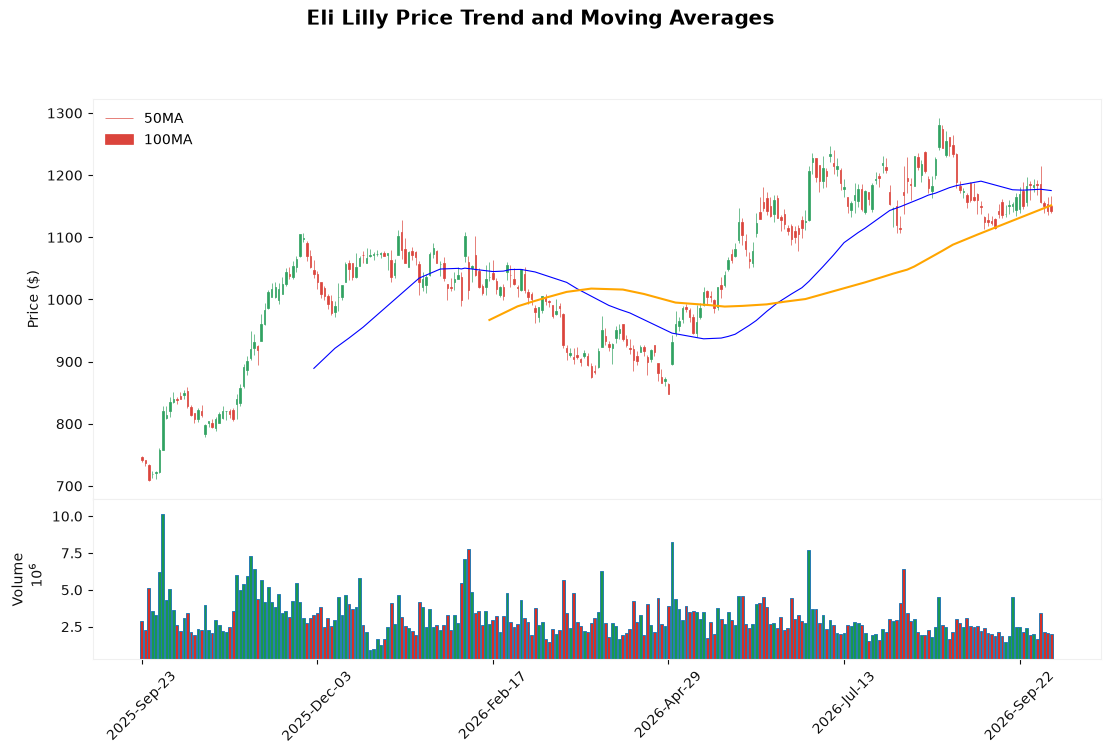

In [101]:
mc1 = mpf.make_marketcolors(
    up="#1a9850",
    down="#d73027",
    edge="inherit",
    wick="inherit",
    volume="inherit"
)


style1 = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    marketcolors=mc1,
    gridstyle="--",
    gridcolor="#dddddd",
    facecolor="white",
    figcolor="white",
    y_on_right=False,
    rc={"font.size": 10}
)

fig, axes = mpf.plot(
    TECH,
    type="candle",
    style=style1,
    addplot=[sma50, sma100],
    volume=True,
    figsize=(14, 8),
    title="Eli Lilly Price Trend and Moving Averages",
    ylabel="Price ($)",
    ylabel_lower="Volume",
    returnfig=True
)

for ax in axes:
    ax.grid(False)


axes[0].legend(
    ["50MA", "100MA"],
    loc="upper left",
    frameon=False
)

plt.show()

In [102]:
fig.savefig('Eli_lilly_technicals.png', dpi=300, bbox_inches='tight')

In [103]:
LROR= np.log(Monte).diff(1)

In [104]:
Mean = LROR.mean()

In [105]:
Vol= LROR.std()

In [106]:
Last_Price = Monte.iloc[-1].item()

In [107]:
Trading_days = 252

In [108]:
Simulation = 10000

In [109]:
Random_Returns = np.random.normal(Mean, Vol,(Trading_days, Simulation))

In [110]:
Simulated_Prices = Last_Price * np.exp(np.cumsum(Random_Returns, axis =0))

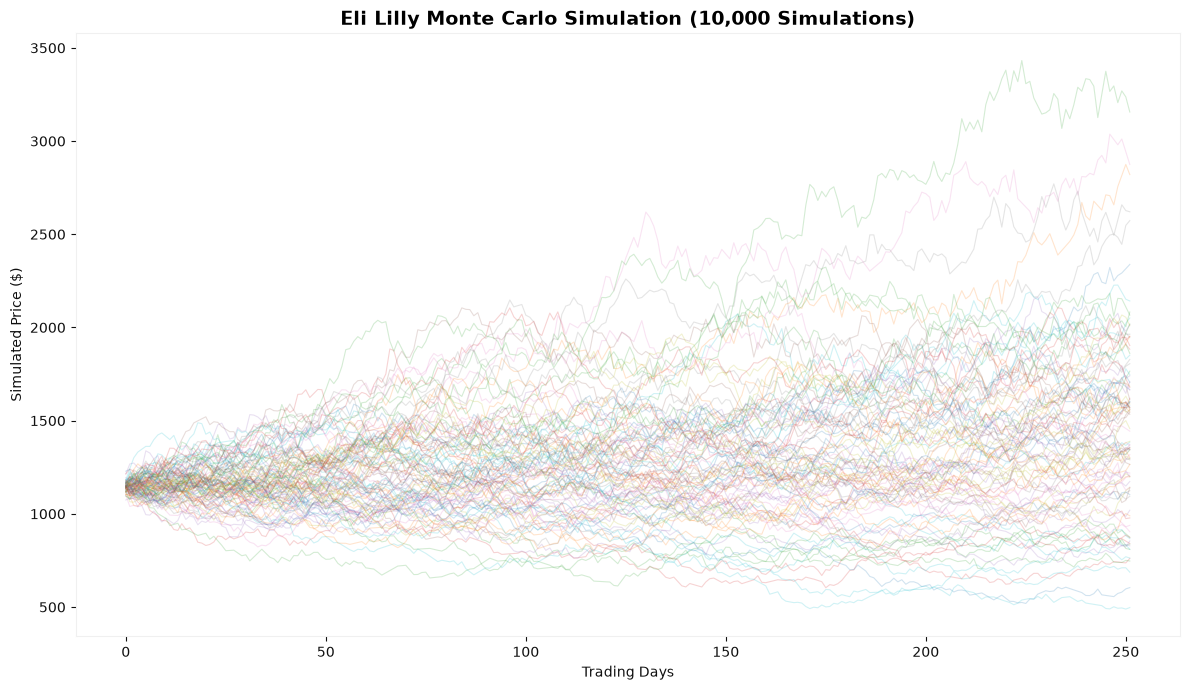

In [111]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    Simulated_Prices[:, :100],
    alpha=0.20,
    linewidth=0.8
)

ax.set_title(
    'Eli Lilly Monte Carlo Simulation (10,000 Simulations)',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Trading Days')
ax.set_ylabel('Simulated Price ($)')

ax.grid(False)

fig.tight_layout()

plt.show()

In [112]:
fig.savefig('Eli_Lilly_Monte.png', dpi=300, bbox_inches='tight')

In [113]:
Final_Price = Simulated_Prices[-1]

In [114]:
Mean_Final_Price = np.mean(Final_Price)
Median_Final_Price = np.median(Final_Price)
Percentile_5 = np.percentile(Final_Price, 5)
Percentile_25 = np.percentile(Final_Price, 25)
Percentile_75 = np.percentile(Final_Price, 75)
Percentile_95 = np.percentile(Final_Price, 95)

In [115]:
Probability_profit = np.mean(Final_Price>Last_Price)

In [116]:
Probability_loss = np.mean(Final_Price<Last_Price)

In [117]:
HIST_SUMMARY = pd.DataFrame({'Annualized Returns': ANN_EXPR, 
                             'Annualized Volatility': ANN_VOL, 
                             'Beta': Beta, 
                             'Sharpe': Sharpe,
                             'Sortino': Sortino,
                             'CAPM': CAPM,
                             'Maximum Drawdown': HMax})

In [118]:
YTD_SUMMARY = pd.DataFrame({'Actual Return': YTD_RET,
                             'Actual Volatility': YTD_VOL,
                             'Maximum Drawdown': YMax,
                             'Sharpe Ratio': YSharpe,
                           'Sortino Ratio': YSortino})

In [119]:
HIST_SUMMARY

,Annualized Returns,Annualized Volatility,Beta,Sharpe,Sortino,CAPM,Maximum Drawdown
Eli_Lilly,0.419754,0.339686,0.657143,1.151515,1.830794,0.123383,-0.344750
Novo_Nordisk,0.172335,0.348036,0.604382,0.412990,0.576483,0.117716,-0.684951
SP500,0.160209,0.207482,1.000000,0.634317,0.891310,0.160209,-0.337173
Healthcare,0.102299,0.181623,0.686590,0.405782,0.576881,0.126546,-0.284043


In [120]:
YTD_SUMMARY

,Actual Return,Actual Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio
Eli_Lilly,0.063203,0.367738,-0.230540,0.069080,0.111099
Novo_Nordisk,-0.247680,0.478561,-0.436699,-0.596538,-0.765503
SP500,0.143027,0.131381,-0.088850,0.800932,1.203595
Healthcare,0.089610,0.166278,-0.104699,0.311586,0.496965


In [121]:
MONTE_SUMMARY = pd.DataFrame({'Current Price': Last_Price,
                        'Mean Simulated Price': Mean_Final_Price,
                        'Median Simulated Price': Median_Final_Price,
                        '5th Percentile': Percentile_5,
                        '25th Percentile': Percentile_25,
                        '75th Percentile': Percentile_75,
                        '95th Percentile': Percentile_95, 
                        'Probability of Profit': Probability_profit,
                        'Probability of loss': Probability_loss}, index =[0])

In [122]:
MONTE_SUMMARY

,Current Price,Mean Simulated Price,Median Simulated Price,5th Percentile,25th Percentile,75th Percentile,95th Percentile,Probability of Profit,Probability of loss
0,1143.119995,1558.204781,1460.229525,808.310022,1151.966559,1864.124581,2632.641417,0.7573,0.2427


In [123]:
LLY_FIN = pd.DataFrame({
    "Period": [
        "FY2020", "FY2021", "FY2022", "FY2023",
        "FY2024", "FY2025", "H1 2026"
    ],

    "Revenue": [
        24.54, 28.32, 28.54, 34.12,
        45.04, 65.18, 42.77
    ],

    "Free_Cash_Flow": [
        5.11, 6.06, 5.73, 0.79,
        3.76, 8.97, 10.76
    ],

    "Gross_Profit": [
        19.06, 21.01, 21.91, 27.04,
        36.63, 54.13, 35.93
    ],

    "Gross_Margin": [
        77.7, 74.2, 76.8, 79.2,
        81.3, 83.0, 84.0
    ],

    "Operating_Income": [
        6.06, 6.36, 7.13, 6.46,
        12.90, 26.30, 17.89
    ],

    "Operating_Margin": [
        24.7, 22.4, 25.0, 18.9,
        28.6, 40.4, 41.8
    ],

    "Net_Income": [
        6.19, 5.58, 6.24, 5.24,
        10.59, 20.64, 14.49
    ],

    "Net_Margin": [
        25.2, 19.7, 21.9, 15.4,
        23.5, 31.7, 33.9
    ],

    "Diluted_EPS": [
        6.79, 6.12, 6.90, 5.80,
        11.71, 22.95, 16.19
    ]
})

LLY_FIN.set_index("Period", inplace=True)

In [124]:
LLY_FIN.head()

,Revenue,Free_Cash_Flow,Gross_Profit,Gross_Margin,Operating_Income,Operating_Margin,Net_Income,Net_Margin,Diluted_EPS
Period,,,,,,,,,
FY2020,24.54,5.11,19.06,77.7,6.06,24.7,6.19,25.2,6.79
FY2021,28.32,6.06,21.01,74.2,6.36,22.4,5.58,19.7,6.12
FY2022,28.54,5.73,21.91,76.8,7.13,25.0,6.24,21.9,6.90
FY2023,34.12,0.79,27.04,79.2,6.46,18.9,5.24,15.4,5.80
FY2024,45.04,3.76,36.63,81.3,12.90,28.6,10.59,23.5,11.71


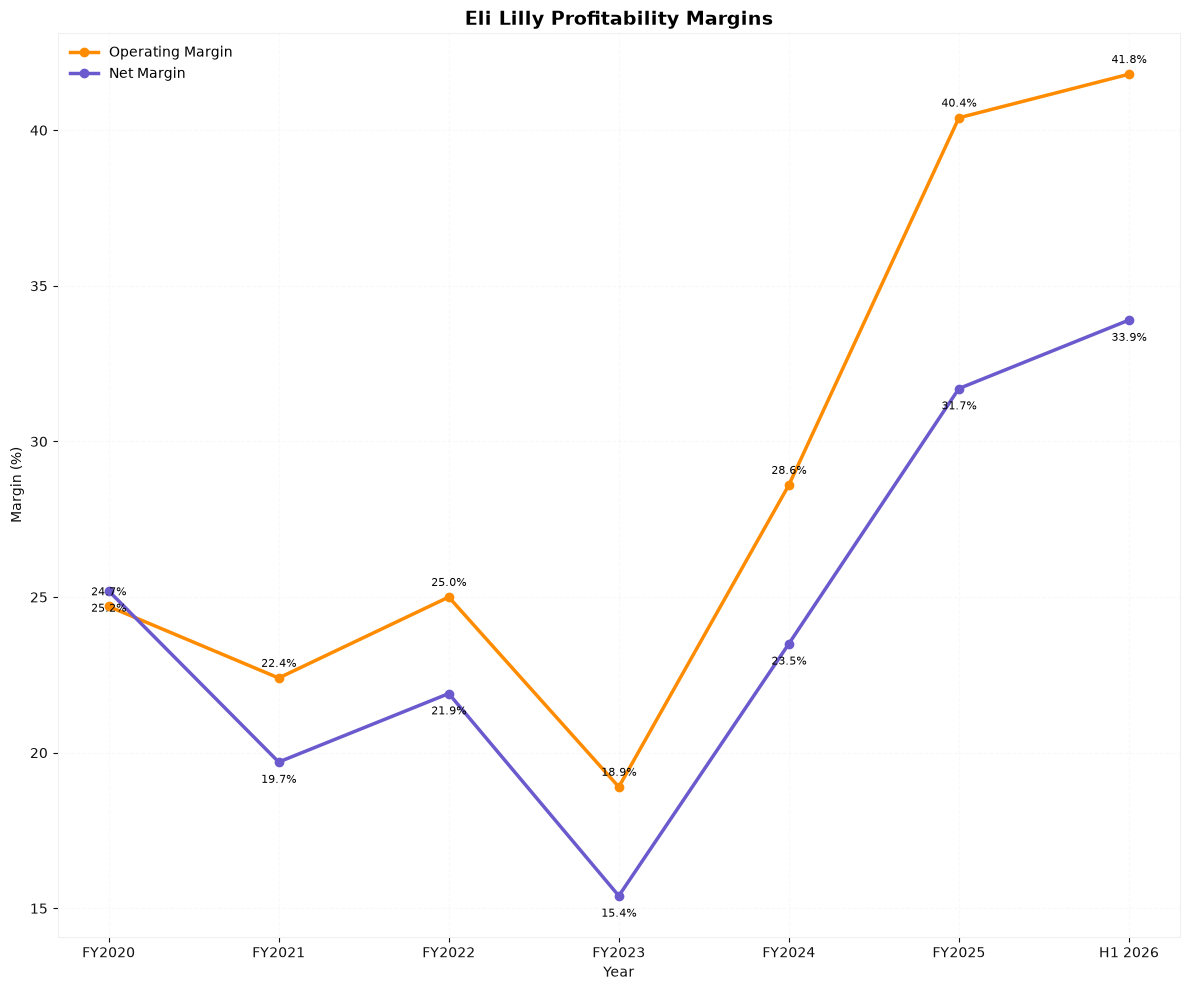

In [125]:
fig, axes = plt.subplots(figsize=(12, 10))

axes.plot(
    LLY_FIN.index,
    LLY_FIN["Operating_Margin"],
    marker="o",
    linewidth=2.5,
    color="#ff8c00",
    label="Operating Margin"
)

axes.plot(
    LLY_FIN.index,
    LLY_FIN["Net_Margin"],
    marker="o",
    linewidth=2.5,
    color="#6a5acd",
    label="Net Margin"
)

for year, value in LLY_FIN["Operating_Margin"].items():
    axes.annotate(
        f"{value:.1f}%",
        (year, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

for year, value in LLY_FIN["Net_Margin"].items():
    axes.annotate(
        f"{value:.1f}%",
        (year, value),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=8
    )

axes.set_title(
    "Eli Lilly Profitability Margins",
    fontsize=14,
    fontweight="bold"
)

axes.set_xlabel("Year")
axes.set_ylabel("Margin (%)")
axes.grid(alpha=0.15)
axes.legend(frameon=False)

plt.tight_layout()
plt.show()

In [126]:
fig.savefig('eli_lilly_profitability.png', dpi=300, bbox_inches ='tight')

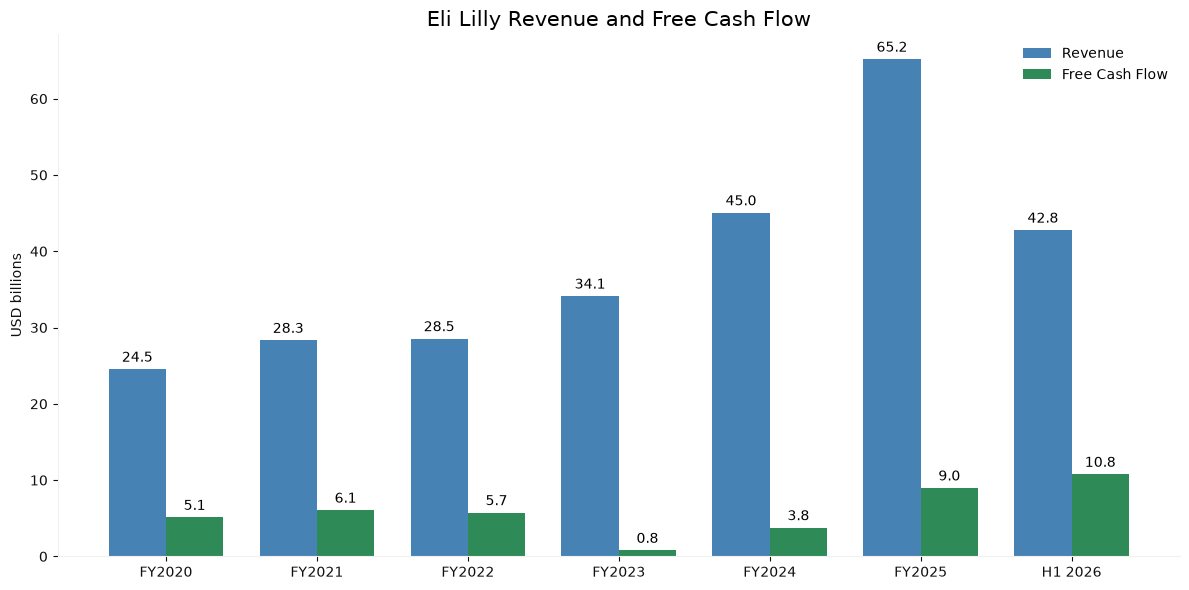

In [127]:
data = LLY_FIN

x = np.arange(len(data.index))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

revenue_bars = ax.bar(
    x - width/2,
    data["Revenue"],
    width,
    label="Revenue",
    color="steelblue"
)

fcf_bars = ax.bar(
    x + width/2,
    data["Free_Cash_Flow"],
    width,
    label="Free Cash Flow",
    color="seagreen"
)

ax.set_title("Eli Lilly Revenue and Free Cash Flow", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("USD billions")
ax.set_xticks(x)
ax.set_xticklabels(data.index)
ax.legend(frameon=False)


ax.grid(False)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.bar_label(revenue_bars, fmt="%.1f", padding=3)
ax.bar_label(fcf_bars, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

In [128]:
fig.savefig('eli_fin_cash.png', dpi=300, bbox_inches='tight')